In [3]:
# Uninstall potentially conflicting versions first
#!pip uninstall transformers huggingface_hub -y -q

# Install required libraries with version constraints
!pip install 'transformers<5' -q
!pip install 'datasets<3' -q
!pip install pytesseract -q
!pip install pdf2image -q
!pip install Pillow -q
!pip install torch torchvision -q  # PyTorch - already on Kaggle but good to confirm
!pip install evaluate -q           # for accuracy metrics
!pip install scikit-learn -q       # for confusion matrix
!pip install seqeval -q            # for NER/extraction metrics later

# Install Tesseract OCR engine (system level)
!sudo apt-get install tesseract-ocr -y -q
!sudo apt-get install poppler-utils -y -q  # needed for pdf2image

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 85.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 13.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.

In [1]:
import torch
import transformers
import datasets

# Check GPU is available
print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")
print("Transformers version:", transformers.__version__)
print("Datasets version:", datasets.__version__)

PyTorch version: 2.11.0+cpu
GPU available: False
GPU name: No GPU
Transformers version: 4.57.6
Datasets version: 2.21.0


In [ ]:
from datasets import load_dataset

# Load RVL-CDIP directly from HuggingFace
# We use a 10% sample - still 40,000 documents, more than enough

dataset = load_dataset(
    "aharley/rvl_cdip",
    split = {
        "train": "train[:8%]",
        "validation": "validation[:10%]",
        "test": "train[:10%]"
    }
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


The repository for aharley/rvl_cdip contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/aharley/rvl_cdip.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


Generating train split:   0%|          | 0/320000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/40000 [00:00<?, ? examples/s]

In [2]:
print("✓ Dataset loaded")
print(dataset)

✓ Dataset loaded


NameError: name 'dataset' is not defined

In [8]:
# See the structure
print("=== DATASET STRUCTURE ===")
print(dataset)

print("\n=== ONE SAMPLE ===")
sample = dataset['train'][0]
print("Keys in each sample:", sample.keys())
print("Label:", sample['label'])
print("Image type:", type(sample['image']))
print("Image size:", sample['image'].size)

=== DATASET STRUCTURE ===
DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 25600
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 4000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 32000
    })
})

=== ONE SAMPLE ===
Keys in each sample: dict_keys(['image', 'label'])
Label: 11
Image type: <class 'PIL.Image.Image'>
Image size: (762, 1000)


In [7]:
# These are the 16 document types in RVL-CDIP
label_names = [
    "letter",        # 0
    "form",          # 1
    "email",         # 2
    "handwritten",   # 3
    "advertisement", # 4
    "scientific report", # 5
    "scientific publication", # 6
    "specification", # 7
    "file folder",   # 8
    "news article",  # 9
    "budget",        # 10
    "invoice",       # 11
    "presentation",  # 12
    "questionnaire", # 13
    "resume",        # 14
    "memo"           # 15
]

# Count how many samples per class in training set
from collections import Counter

labels = dataset['train']['label']
label_counts = Counter(labels)

print("=== SAMPLES PER CLASS ===")
for label_id, count in sorted(label_counts.items()):
    print(f"  {label_names[label_id]:<25} | {count:>5} samples")

=== SAMPLES PER CLASS ===
  letter                    |  1604 samples
  form                      |  1584 samples
  email                     |  1611 samples
  handwritten               |  1613 samples
  advertisement             |  1578 samples
  scientific report         |  1596 samples
  scientific publication    |  1626 samples
  specification             |  1582 samples
  file folder               |  1667 samples
  news article              |  1601 samples
  budget                    |  1566 samples
  invoice                   |  1606 samples
  presentation              |  1590 samples
  questionnaire             |  1603 samples
  resume                    |  1574 samples
  memo                      |  1599 samples


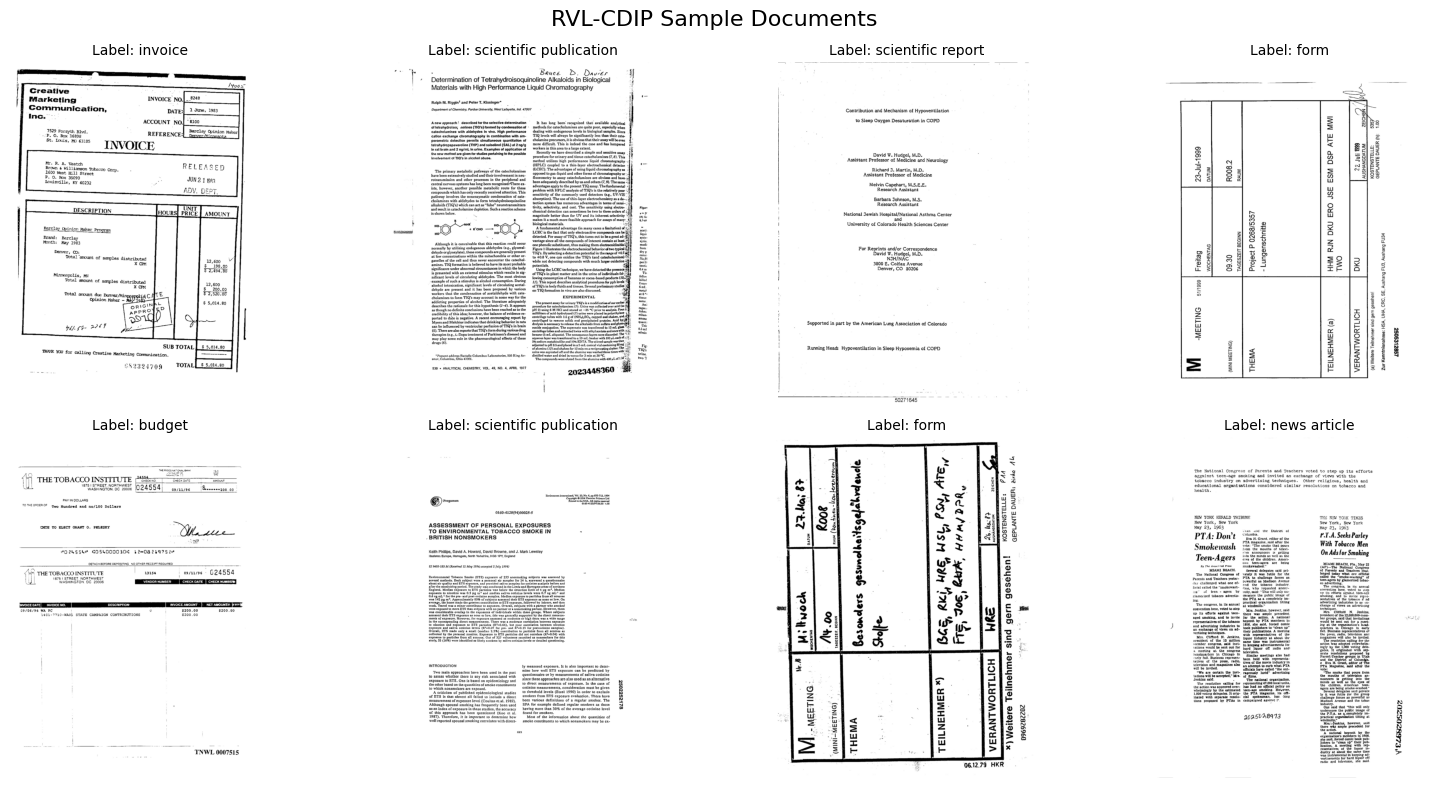

✓ Plot saved to Google Drive


In [8]:
import matplotlib.pyplot as plt
import os # Import the os module to handle directory operations

# Display 8 sample documents with their labels
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("RVL-CDIP Sample Documents", fontsize=16)

for i, ax in enumerate(axes.flatten()):
    sample = dataset['train'][i * 50]  # spread samples out
    ax.imshow(sample['image'], cmap='gray')
    ax.set_title(f"Label: {label_names[sample['label']]}", fontsize=10)
    ax.axis('off')

plt.tight_layout()

# Define the directory path
save_dir = '/content/drive/MyDrive/DocumentChecker/'
# Create the directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

plt.savefig(os.path.join(save_dir, 'sample_documents.png'))
plt.show()
print("✓ Plot saved to Google Drive")

In [9]:
import numpy as np
from PIL import Image

print("=== DATA QUALITY CHECK ===\n")

small_images   = 0
very_dark      = 0
very_light     = 0
unusual_aspect = 0

# Check first 500 samples
for i in range(500):
    sample = dataset['train'][i]
    img    = sample['image']
    w, h   = img.size

    # Check image size
    if w < 100 or h < 100:
        small_images += 1

    # Check brightness (convert to grayscale numpy array)
    img_array = np.array(img.convert('L'))
    mean_brightness = img_array.mean()

    if mean_brightness < 50:   # very dark
        very_dark += 1
    if mean_brightness > 230:  # very light / nearly blank
        very_light += 1

    # Check unusual aspect ratios
    aspect_ratio = w / h
    if aspect_ratio > 2.0 or aspect_ratio < 0.3:
        unusual_aspect += 1

print(f"Checked 500 samples:")
print(f"  Small/low-res images  : {small_images}")
print(f"  Very dark images      : {very_dark}")
print(f"  Very light/blank      : {very_light}")
print(f"  Unusual aspect ratios : {unusual_aspect}")
print(f"\nThese are the issues we will fix in Stage 3 ✓")

=== DATA QUALITY CHECK ===

Checked 500 samples:
  Small/low-res images  : 0
  Very dark images      : 1
  Very light/blank      : 408
  Unusual aspect ratios : 0

These are the issues we will fix in Stage 3 ✓


Tring to solve some error

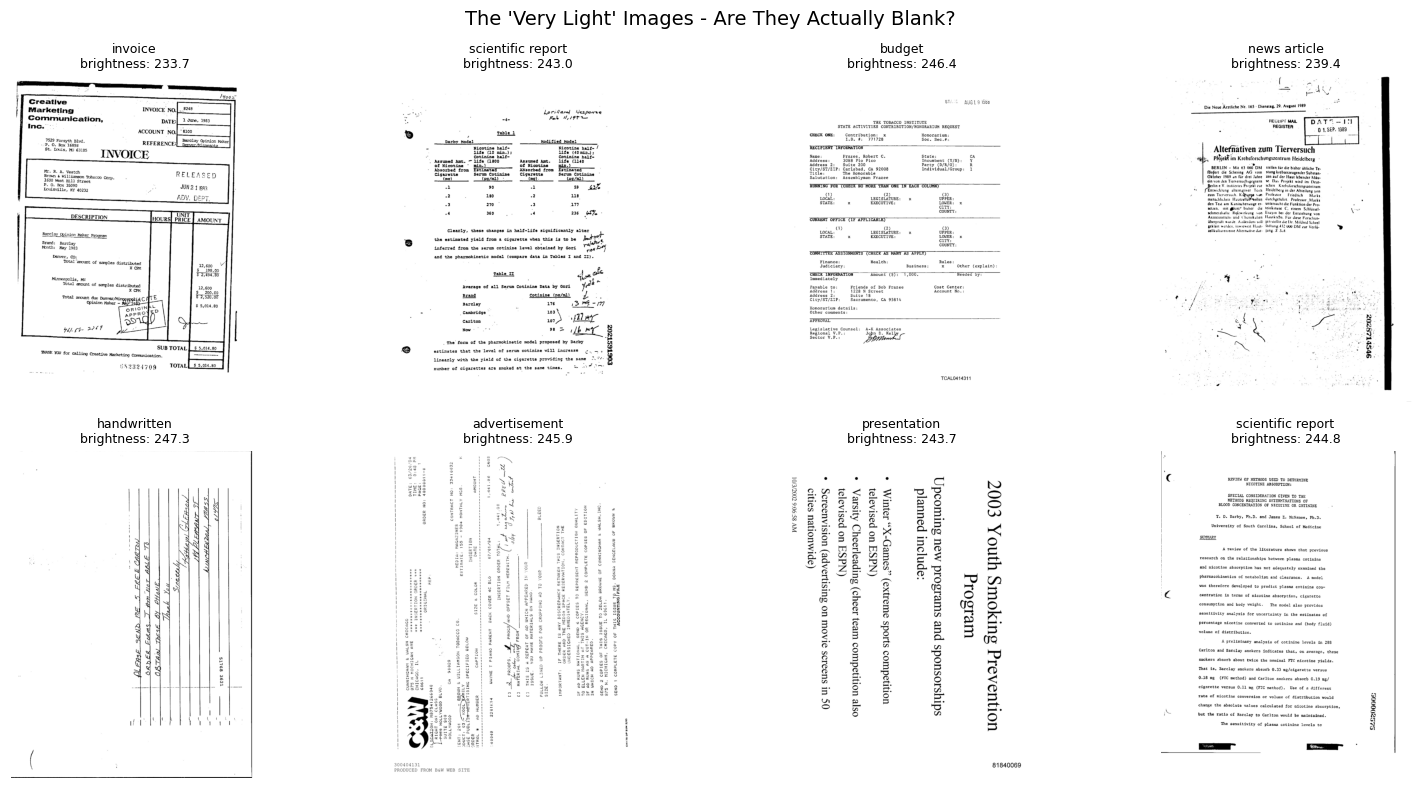

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Find some of the "very light" images and display them
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("The 'Very Light' Images - Are They Actually Blank?", fontsize=14)

light_samples = []
for i in range(1000):
    sample = dataset['train'][i]
    img_array = np.array(sample['image'].convert('L'))
    if img_array.mean() > 230:
        light_samples.append(sample)
    if len(light_samples) == 8:
        break

for i, ax in enumerate(axes.flatten()):
    ax.imshow(light_samples[i]['image'], cmap='gray')
    img_array = np.array(light_samples[i]['image'].convert('L'))
    ax.set_title(f"{label_names[light_samples[i]['label']]}\nbrightness: {img_array.mean():.1f}", fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DocumentChecker/light_images_check.png')
plt.show()

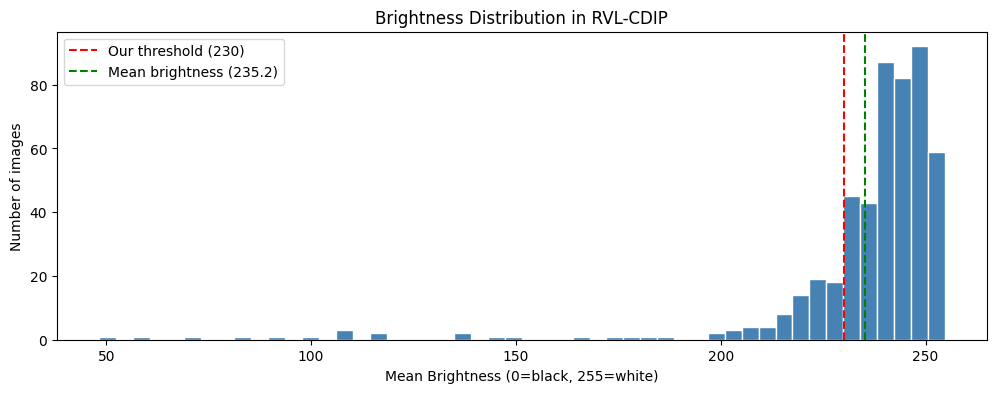

Min brightness  : 48.3
Max brightness  : 254.7
Mean brightness : 235.2
Median          : 241.7

Truly blank (>250): 67 out of 500


In [11]:
# Plot brightness distribution across 500 samples
brightnesses = []

for i in range(500):
    sample = dataset['train'][i]
    img_array = np.array(sample['image'].convert('L'))
    brightnesses.append(img_array.mean())

plt.figure(figsize=(12, 4))
plt.hist(brightnesses, bins=50, color='steelblue', edgecolor='white')
plt.axvline(x=230, color='red', linestyle='--', label='Our threshold (230)')
plt.axvline(x=np.mean(brightnesses), color='green', linestyle='--',
            label=f'Mean brightness ({np.mean(brightnesses):.1f})')
plt.xlabel('Mean Brightness (0=black, 255=white)')
plt.ylabel('Number of images')
plt.title('Brightness Distribution in RVL-CDIP')
plt.legend()
plt.savefig('/content/drive/MyDrive/DocumentChecker/brightness_distribution.png')
plt.show()

print(f"Min brightness  : {min(brightnesses):.1f}")
print(f"Max brightness  : {max(brightnesses):.1f}")
print(f"Mean brightness : {np.mean(brightnesses):.1f}")
print(f"Median          : {np.median(brightnesses):.1f}")

# How many are truly blank (very little contrast)
truly_blank = sum(1 for b in brightnesses if b > 250)
print(f"\nTruly blank (>250): {truly_blank} out of 500")

In [12]:
# Blank images have HIGH brightness AND LOW contrast (std deviation)
# A document with text will have high contrast even if background is light

truly_problematic = 0
normal_but_light  = 0

for i in range(500):
    sample = dataset['train'][i]
    img_array = np.array(sample['image'].convert('L'))

    mean_brightness = img_array.mean()
    std_contrast    = img_array.std()  # low std = blank, high std = has content

    if mean_brightness > 230 and std_contrast < 10:
        truly_problematic += 1  # actually blank
    elif mean_brightness > 230 and std_contrast >= 10:
        normal_but_light += 1   # light background but has content

print("=== REVISED QUALITY CHECK ===")
print(f"Truly blank (light + no contrast) : {truly_problematic}")
print(f"Light background but has content  : {normal_but_light}")
print(f"\nOur original threshold was wrong!")
print(f"Most 'light' images are just scanned docs with white backgrounds ✓")

=== REVISED QUALITY CHECK ===
Truly blank (light + no contrast) : 1
Light background but has content  : 407

Our original threshold was wrong!
Most 'light' images are just scanned docs with white backgrounds ✓


Cleaning and Preprocessing

In [13]:
import numpy as np
from PIL import Image, ImageOps, ImageFilter
from collections import Counter
import matplotlib.pyplot as plt

print("=== REAL ISSUES TO FIX ===")
print("1. Truly blank images (brightness > 250 AND std < 10)")
print("2. Class imbalance (some document types have more samples)")
print("3. Inconsistent image sizes (model needs fixed input size)")
print("4. Images needing contrast enhancement (washed out scans)")
print("5. Grayscale vs RGB inconsistency")

=== REAL ISSUES TO FIX ===
1. Truly blank images (brightness > 250 AND std < 10)
2. Class imbalance (some document types have more samples)
3. Inconsistent image sizes (model needs fixed input size)
4. Images needing contrast enhancement (washed out scans)
5. Grayscale vs RGB inconsistency


check class Imbalance

In [14]:
from collections import Counter

labels = dataset['train']['label']
label_counts = Counter(labels)

print("=== CLASS DISTRIBUTION ===")
max_count = max(label_counts.values())
min_count = min(label_counts.values())

for label_id, count in sorted(label_counts.items()):
    bar = "█" * (count // 50)
    print(f"  {label_names[label_id]:<25} | {count:>5} | {bar}")

print(f"\nLargest class  : {max_count}")
print(f"Smallest class : {min_count}")
print(f"Imbalance ratio: {max_count/min_count:.2f}x")

if max_count / min_count > 2:
    print("⚠️  Significant imbalance — we need to handle this")
else:
    print("✓  Classes are reasonably balanced")

=== CLASS DISTRIBUTION ===
  letter                    |  1604 | ████████████████████████████████
  form                      |  1584 | ███████████████████████████████
  email                     |  1611 | ████████████████████████████████
  handwritten               |  1613 | ████████████████████████████████
  advertisement             |  1578 | ███████████████████████████████
  scientific report         |  1596 | ███████████████████████████████
  scientific publication    |  1626 | ████████████████████████████████
  specification             |  1582 | ███████████████████████████████
  file folder               |  1667 | █████████████████████████████████
  news article              |  1601 | ████████████████████████████████
  budget                    |  1566 | ███████████████████████████████
  invoice                   |  1606 | ████████████████████████████████
  presentation              |  1590 | ███████████████████████████████
  questionnaire             |  1603 | █████████████████

Build the cleaning functions

In [15]:
from PIL import Image, ImageOps, ImageEnhance
import numpy as np

def is_blank(image, brightness_threshold=250, contrast_threshold=10):
    """Detect truly blank/useless images"""
    img_array = np.array(image.convert('L'))
    return img_array.mean() > brightness_threshold and img_array.std() < contrast_threshold

def clean_image(image, target_size=(224, 224)):
    """
    Full cleaning pipeline for one document image.
    Steps:
      1. Convert to RGB (some are grayscale, model needs RGB)
      2. Enhance contrast if image is washed out
      3. Resize to fixed size the model expects
      4. Normalize pixel values
    """
    # Step 1: Convert to RGB
    # Some scans are grayscale (L mode) or RGBA
    # LayoutLMv3 expects RGB (3 channels)
    if image.mode != 'RGB':
        image = image.convert('RGB')

    # Step 2: Enhance contrast if washed out
    # We check contrast of grayscale version
    gray = np.array(image.convert('L'))
    if gray.std() < 40:  # low contrast = washed out scan
        enhancer = ImageEnhance.Contrast(image)
        image = enhancer.enhance(2.0)  # double the contrast

    # Step 3: Resize to 224x224 (standard for vision transformers)
    image = image.resize(target_size, Image.LANCZOS)

    return image

# Test the function on a few samples
print("Testing clean_image function...")
for i in range(5):
    sample  = dataset['train'][i * 100]
    original = sample['image']
    cleaned  = clean_image(original)

    print(f"Sample {i}: {original.mode} {original.size} → {cleaned.mode} {cleaned.size}")

print("\n✓ clean_image function works correctly")

Testing clean_image function...
Sample 0: L (762, 1000) → RGB (224, 224)
Sample 1: L (754, 1000) → RGB (224, 224)
Sample 2: L (754, 1000) → RGB (224, 224)
Sample 3: L (777, 1000) → RGB (224, 224)
Sample 4: L (776, 1000) → RGB (224, 224)

✓ clean_image function works correctly


Apply Cleaning to the dataset

In [16]:
def preprocess_dataset(split):
    """
    Apply cleaning to an entire dataset split.
    Removes blank images and cleans the rest.
    """
    cleaned_images = []
    cleaned_labels = []
    removed        = 0

    total = len(split)
    print(f"Processing {total} samples...")

    for i, sample in enumerate(split):
        # Progress update every 1000 samples
        if i % 1000 == 0:
            print(f"  {i}/{total} processed, {removed} removed so far...")

        image = sample['image']
        label = sample['label']

        # Skip truly blank images
        if is_blank(image):
            removed += 1
            continue

        # Clean the image
        cleaned = clean_image(image)

        cleaned_images.append(cleaned)
        cleaned_labels.append(label)

    print(f"\n✓ Done! Removed {removed} blank images")
    print(f"✓ Kept {len(cleaned_images)} clean samples")
    return cleaned_images, cleaned_labels




Apply to all split

In [17]:
# Apply to all splits
print("=== CLEANING TRAINING SET ===")
train_images, train_labels = preprocess_dataset(dataset['train'])


=== CLEANING TRAINING SET ===
Processing 25600 samples...
  0/25600 processed, 0 removed so far...
  1000/25600 processed, 5 removed so far...
  2000/25600 processed, 9 removed so far...
  3000/25600 processed, 15 removed so far...
  4000/25600 processed, 25 removed so far...
  5000/25600 processed, 31 removed so far...
  6000/25600 processed, 38 removed so far...
  7000/25600 processed, 47 removed so far...
  8000/25600 processed, 57 removed so far...
  9000/25600 processed, 66 removed so far...
  10000/25600 processed, 80 removed so far...
  11000/25600 processed, 91 removed so far...
  12000/25600 processed, 97 removed so far...
  13000/25600 processed, 106 removed so far...
  14000/25600 processed, 111 removed so far...
  15000/25600 processed, 119 removed so far...
  16000/25600 processed, 137 removed so far...
  17000/25600 processed, 146 removed so far...
  18000/25600 processed, 155 removed so far...
  19000/25600 processed, 163 removed so far...
  20000/25600 processed, 170 re

In [18]:
print("\n=== CLEANING VALIDATION SET ===")
val_images, val_labels = preprocess_dataset(dataset['validation'])



=== CLEANING VALIDATION SET ===
Processing 4000 samples...
  0/4000 processed, 0 removed so far...
  1000/4000 processed, 8 removed so far...
  2000/4000 processed, 15 removed so far...
  3000/4000 processed, 22 removed so far...

✓ Done! Removed 29 blank images
✓ Kept 3971 clean samples


In [1]:
print("\n=== CLEANING TEST SET ===")
test_images, test_labels = preprocess_dataset(dataset['test'])


=== CLEANING TEST SET ===


NameError: name 'preprocess_dataset' is not defined

Save cleaned data to google drive

In [ ]:
import pickle

# Save everything to Google Drive so you don't lose it if session ends
save_path = '/content/drive/MyDrive/DocumentChecker/data'

print("Saving cleaned data to Google Drive...")

with open(f'{save_path}/train_images.pkl', 'wb') as f:
    pickle.dump(train_images, f)

with open(f'{save_path}/train_labels.pkl', 'wb') as f:
    pickle.dump(train_labels, f)

with open(f'{save_path}/val_images.pkl', 'wb') as f:
    pickle.dump(val_images, f)

with open(f'{save_path}/val_labels.pkl', 'wb') as f:
    pickle.dump(val_labels, f)

with open(f'{save_path}/test_images.pkl', 'wb') as f:
    pickle.dump(test_images, f)

with open(f'{save_path}/test_labels.pkl', 'wb') as f:
    pickle.dump(test_labels, f)

print(f"✓ All cleaned data saved to {save_path}")
print(f"\nFinal dataset sizes:")
print(f"  Train      : {len(train_images)} samples")
print(f"  Validation : {len(val_images)} samples")
print(f"  Test       : {len(test_images)} samples")

Visualize Bofore and After cleaning

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Before vs After Cleaning", fontsize=14)

for i in range(4):
    sample   = dataset['train'][i * 200]
    original = sample['image']
    cleaned  = clean_image(original)

    # Before
    axes[0][i].imshow(original, cmap='gray')
    axes[0][i].set_title(f"Before\n{original.mode} {original.size}", fontsize=9)
    axes[0][i].axis('off')

    # After
    axes[1][i].imshow(cleaned)
    axes[1][i].set_title(f"After\n{cleaned.mode} {cleaned.size}", fontsize=9)
    axes[1][i].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DocumentChecker/before_after_cleaning.png')
plt.show()
print("✓ Comparison saved to Google Drive")